
























# Лабораторная работа №3
## Спектральный анализ и фильтрация сигналов. Фильтры Баттерворта.

## 0. Импорты и параметры сигнала

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp

%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4

# ── Параметры сигнала (используются во всех заданиях) ──────────────────────
fs = 5000                               # частота дискретизации (Гц)
T  = 1.0                                # длительность (с)
N  = int(fs * T)                        # число отсчётов
t  = np.linspace(0, T, N, endpoint=False)

f1, f2, f3 = 50, 150, 450
x = (np.cos(2*np.pi*f1*t) +
     np.cos(2*np.pi*f2*t) +
     np.cos(2*np.pi*f3*t))

# ── Вспомогательные функции ────────────────────────────────────────────────
def fft_spectrum(sig):
    """Возвращает (freqs_pos, амплитуды) для положительных частот."""
    S = np.fft.fft(sig)
    f = np.fft.fftfreq(N, d=1/fs)
    half = N // 2
    return f[:half], (2/N)*np.abs(S[:half]), S, f

def apply_filter_fd(sig, H_full):
    """Фильтрация в частотной области: IFFT(FFT(sig) * H)."""
    return np.real(np.fft.ifft(np.fft.fft(sig) * H_full))

def plot_4(t, x_orig, x_filt, freqs, X_mag, Xf_mag, H_mag,
           fc_label='', title=''):
    """4 графика: исходный / отфильтрованный / спектры / АЧХ."""
    mask = freqs <= 600
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(title, fontsize=12)

    axes[0,0].plot(t[:500], x_orig[:500], 'steelblue')
    axes[0,0].set_title('Исходный сигнал'); axes[0,0].set_xlabel('t, с')

    axes[0,1].plot(t[:500], x_filt[:500], 'darkorange')
    axes[0,1].set_title('Отфильтрованный сигнал'); axes[0,1].set_xlabel('t, с')

    axes[1,0].stem(freqs[mask], X_mag[mask],
                   linefmt='steelblue', markerfmt='C0o', basefmt='k-', label='Исходный')
    axes[1,0].stem(freqs[mask], Xf_mag[mask],
                   linefmt='darkorange', markerfmt='C1o', basefmt='k-', label='Отфильтрованный')
    axes[1,0].set_title('Спектр до/после'); axes[1,0].set_xlabel('f, Гц')
    axes[1,0].legend(fontsize=8)

    axes[1,1].plot(freqs[mask], H_mag[mask], 'crimson', lw=2)
    axes[1,1].set_title(f'АЧХ фильтра {fc_label}'); axes[1,1].set_xlabel('f, Гц')
    axes[1,1].set_ylabel('|H(f)|')

    plt.tight_layout()
    plt.show()

def peak_amp(mag, freq_arr, target, window=3):
    mask = (freq_arr >= target-window) & (freq_arr <= target+window)
    return float(np.max(mag[mask])) if np.any(mask) else 0.0

def print_amps(freqs, X_mag, Xf_mag):
    print(f"{'Частота':>10} | {'До':>8} | {'После':>8} | Осталось")
    print('-'*42)
    for f in [50, 150, 450]:
        a0 = peak_amp(X_mag, freqs, f)
        a1 = peak_amp(Xf_mag, freqs, f)
        print(f"{f:>8} Гц | {a0:>8.4f} | {a1:>8.4f} | {a1/a0*100:.1f}%")

# Базовый спектр исходного сигнала (нужен везде)
freqs_pos, X_mag, X_full, freqs_full = fft_spectrum(x)
print("Параметры сигнала:", f"fs={fs} Гц, N={N}, T={T} с")

Параметры сигнала: fs=5000 Гц, N=5000, T=1.0 с


---
## Задание 1. Спектр сигнала через БПФ

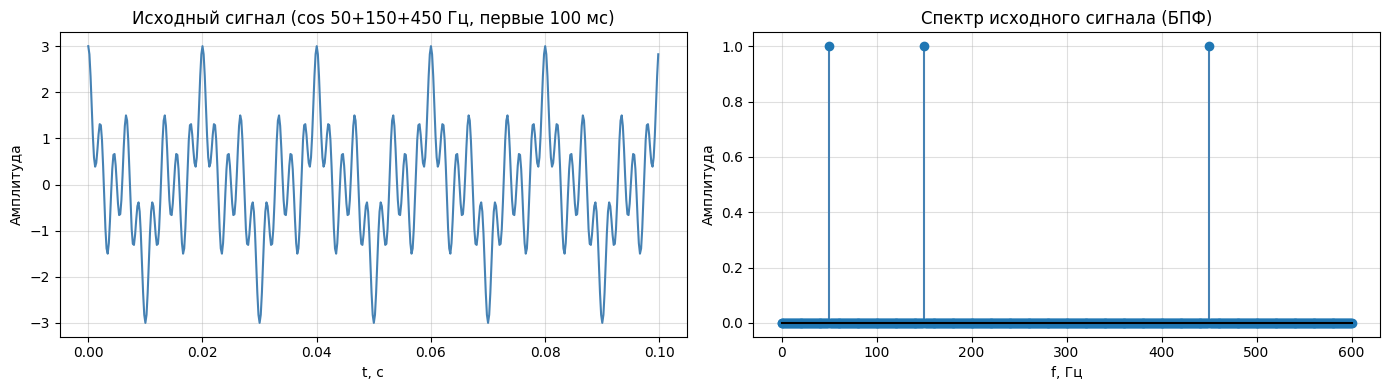

50 Гц → амплитуда = 1.0000
150 Гц → амплитуда = 1.0000
450 Гц → амплитуда = 1.0000


In [2]:
mask600 = freqs_pos <= 600

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t[:500], x[:500], 'steelblue')
axes[0].set_title('Исходный сигнал (cos 50+150+450 Гц, первые 100 мс)')
axes[0].set_xlabel('t, с'); axes[0].set_ylabel('Амплитуда')

axes[1].stem(freqs_pos[mask600], X_mag[mask600],
             linefmt='steelblue', markerfmt='C0o', basefmt='k-')
axes[1].set_title('Спектр исходного сигнала (БПФ)')
axes[1].set_xlabel('f, Гц'); axes[1].set_ylabel('Амплитуда')

plt.tight_layout(); plt.show()

for f in [50, 150, 450]:
    print(f"{f} Гц → амплитуда = {peak_amp(X_mag, freqs_pos, f):.4f}")

---
## Задание 2. ФНЧ Баттерворта 2-го порядка (формула 32)

$$H_{\text{ФНЧ}}(\omega, \omega_c) = \frac{\omega_c^2}{-\omega^2 + j\sqrt{2}\,\omega_c\,\omega + \omega_c^2}$$

Частота среза `fc = 100 Гц` — пропускает 50 Гц, давит 150 и 450 Гц.

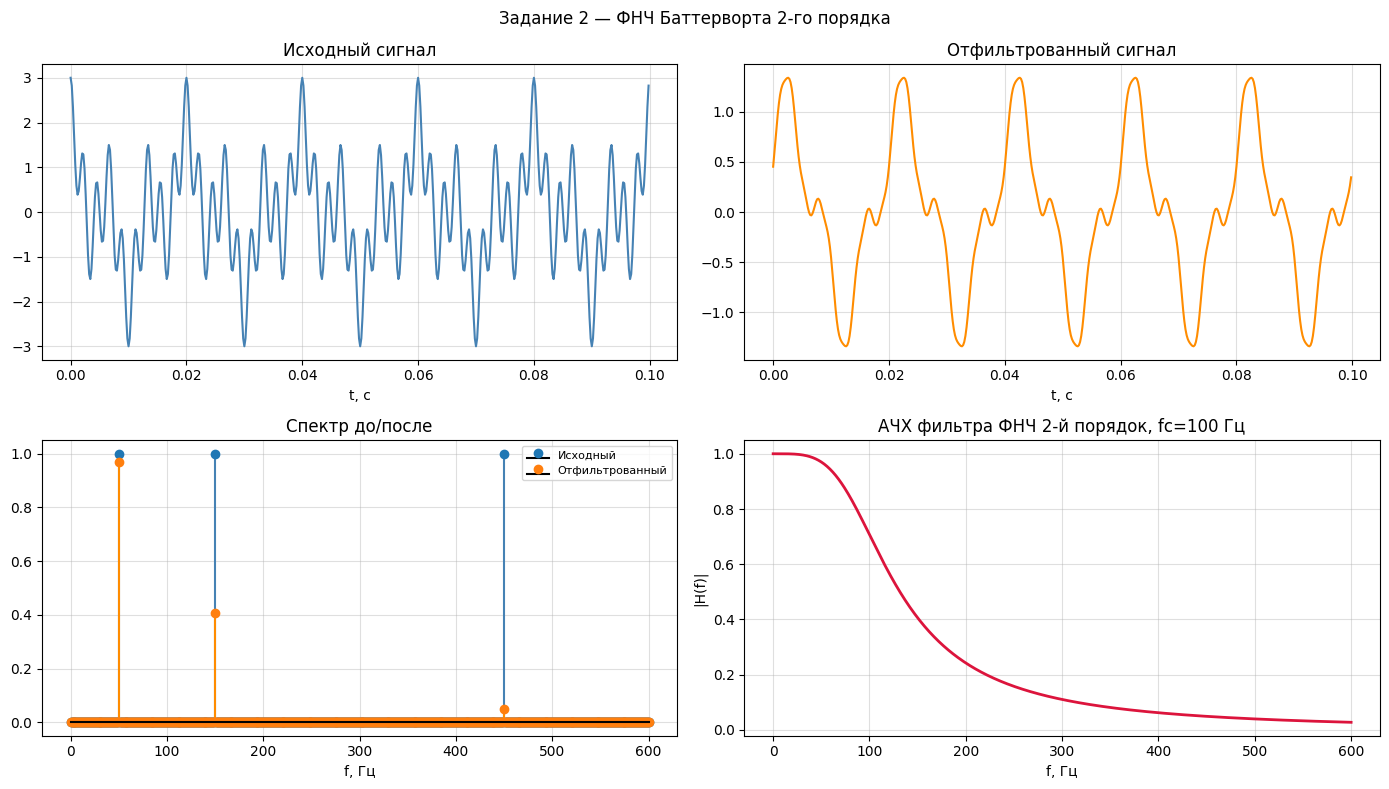

   Частота |       До |    После | Осталось
------------------------------------------
      50 Гц |   1.0000 |   0.9701 | 97.0%
     150 Гц |   1.0000 |   0.4061 | 40.6%
     450 Гц |   1.0000 |   0.0493 | 4.9%


In [3]:
fc_lpf = 100
wc = 2*np.pi*fc_lpf
w  = 2*np.pi*freqs_full

# Формула (32)
H_lpf2 = wc**2 / (-w**2 + 1j*np.sqrt(2)*wc*w + wc**2)

x_lpf2 = apply_filter_fd(x, H_lpf2)
_, Xf_lpf2, _, _ = fft_spectrum(x_lpf2)

plot_4(t, x, x_lpf2, freqs_pos, X_mag, Xf_lpf2,
       np.abs(H_lpf2[:N//2]),
       fc_label=f'ФНЧ 2-й порядок, fc={fc_lpf} Гц',
       title='Задание 2 — ФНЧ Баттерворта 2-го порядка')
print_amps(freqs_pos, X_mag, Xf_lpf2)

---
## Задание 3. ФВЧ Баттерворта 2-го порядка (формула 35)

$$H_{\text{ФВЧ}}(\omega, \omega_c) = \frac{\omega^2}{-\omega_c^2 + j\sqrt{2}\,\omega_c\,\omega + \omega^2}$$

Получается из ФНЧ заменой $\Omega = \omega_c / \omega$ (вместо $\omega / \omega_c$).
Частота среза `fc = 200 Гц` — подавляет 50 и 150 Гц, пропускает 450 Гц.

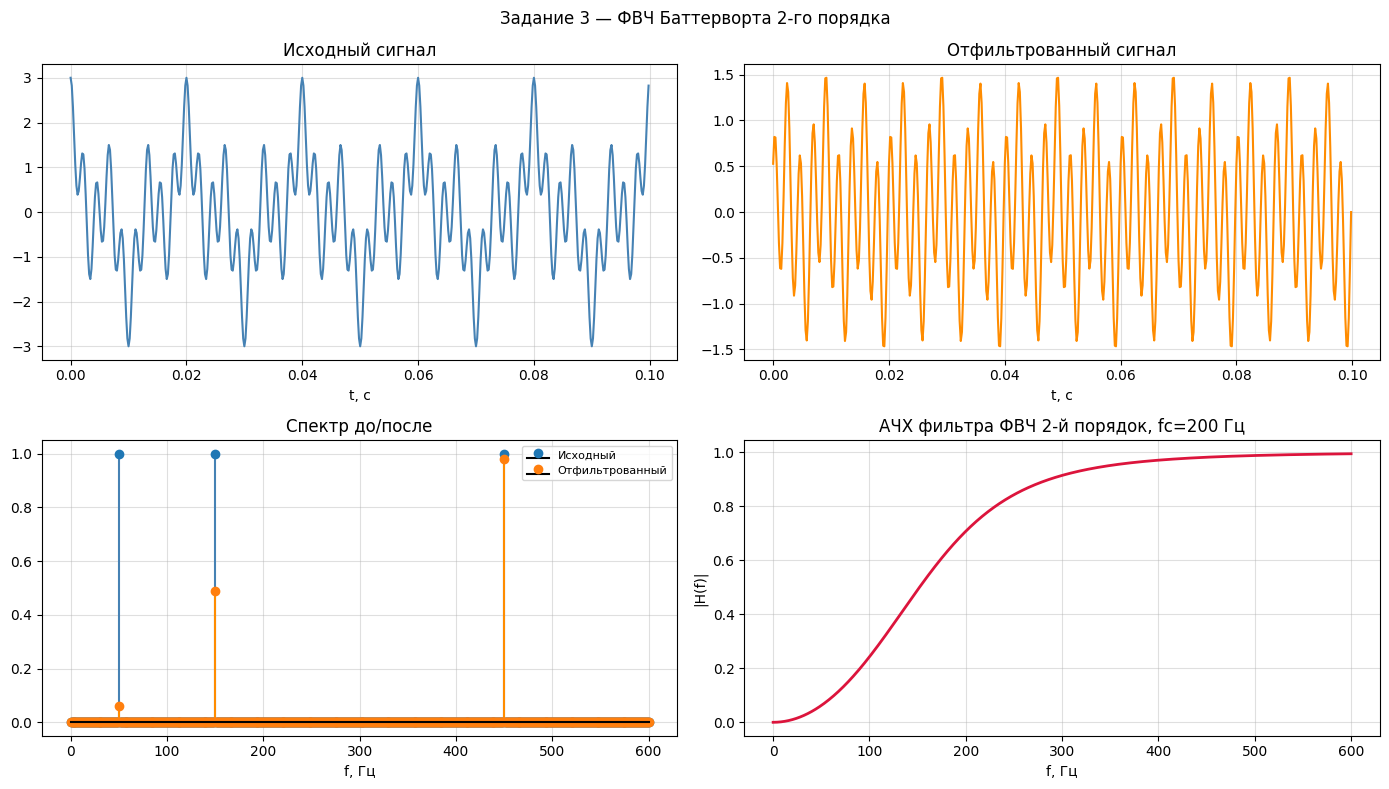

   Частота |       До |    После | Осталось
------------------------------------------
      50 Гц |   1.0000 |   0.0624 | 6.2%
     150 Гц |   1.0000 |   0.4903 | 49.0%
     450 Гц |   1.0000 |   0.9810 | 98.1%


In [4]:
fc_hpf = 200
wc = 2*np.pi*fc_hpf
w  = 2*np.pi*freqs_full

# Формула (35)
H_hpf2 = w**2 / (-wc**2 + 1j*np.sqrt(2)*wc*w + w**2)

x_hpf2 = apply_filter_fd(x, H_hpf2)
_, Xf_hpf2, _, _ = fft_spectrum(x_hpf2)

plot_4(t, x, x_hpf2, freqs_pos, X_mag, Xf_hpf2,
       np.abs(H_hpf2[:N//2]),
       fc_label=f'ФВЧ 2-й порядок, fc={fc_hpf} Гц',
       title='Задание 3 — ФВЧ Баттерворта 2-го порядка')
print_amps(freqs_pos, X_mag, Xf_hpf2)

---
## Задание 4. Полосовой (ПФ) и заграждающий (ЗФ) фильтры на 150 Гц

### Полосовой фильтр (формула 36)
$$H_{\text{ПФ}}(\omega) = H_{\text{ФНЧ}}(\omega,\, \omega_{п1}) \cdot H_{\text{ФВЧ}}(\omega,\, \omega_{п2})$$

Выбираем полосу пропускания вокруг 150 Гц: $\omega_{п1} = 100$ Гц, $\omega_{п2} = 200$ Гц.

### Заграждающий фильтр (формула 38)
$$H_{\text{ЗФ}}(\omega) = H_{\text{ФНЧ}}(\omega,\, \omega_{з1}) + H_{\text{ФВЧ}}(\omega,\, \omega_{з2})$$

Те же граничные частоты — вырезаем полосу вокруг 150 Гц.

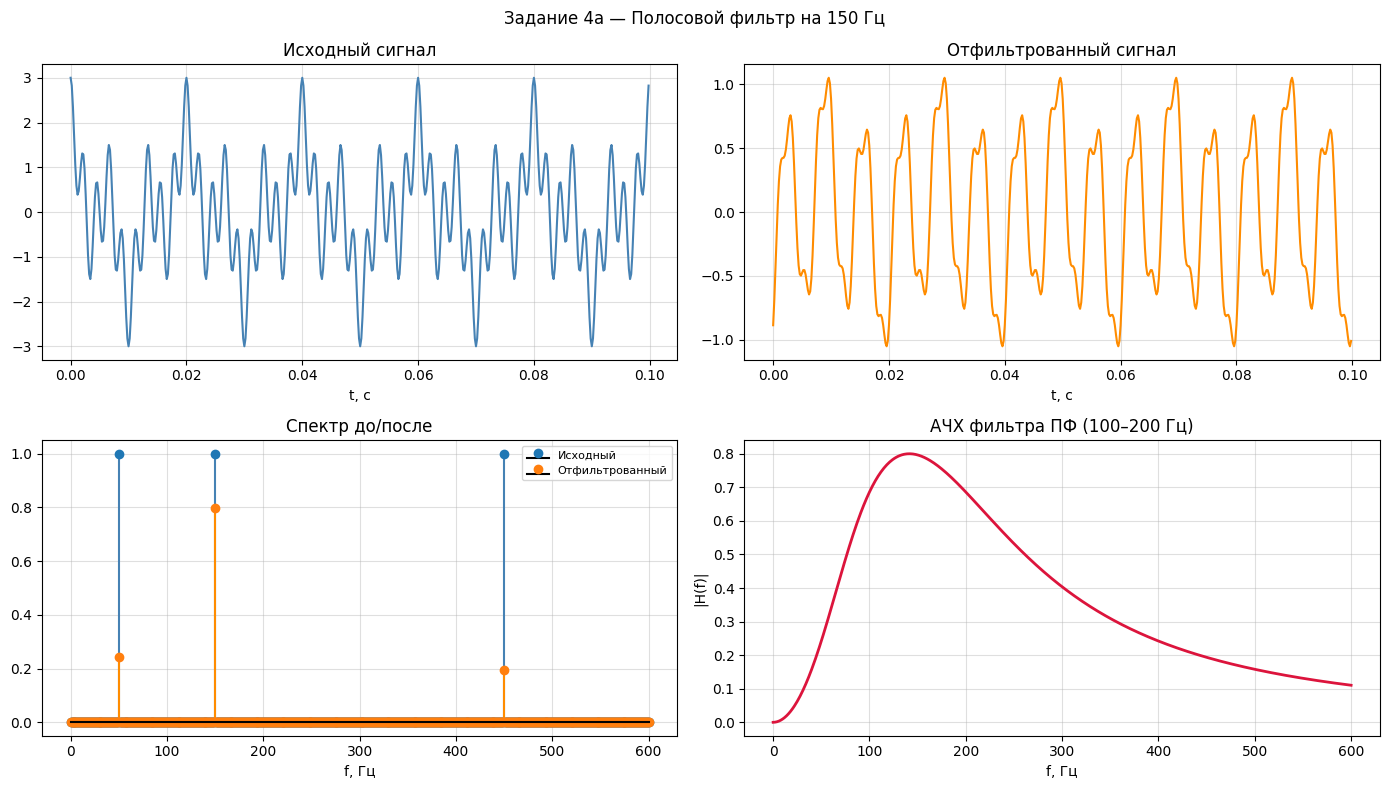

Полосовой фильтр:
   Частота |       До |    После | Осталось
------------------------------------------
      50 Гц |   1.0000 |   0.2421 | 24.2%
     150 Гц |   1.0000 |   0.7965 | 79.6%
     450 Гц |   1.0000 |   0.1936 | 19.4%


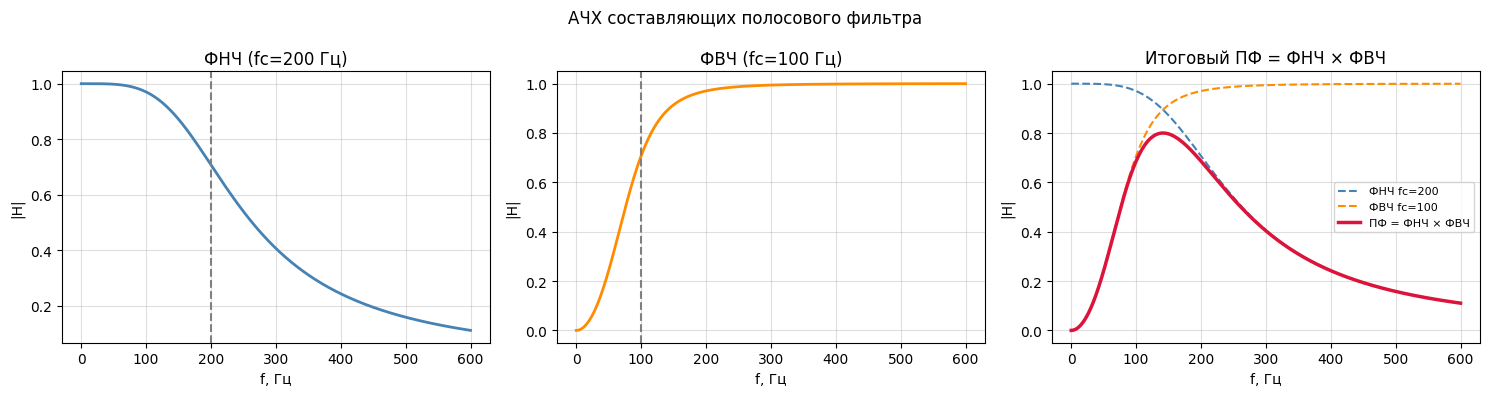

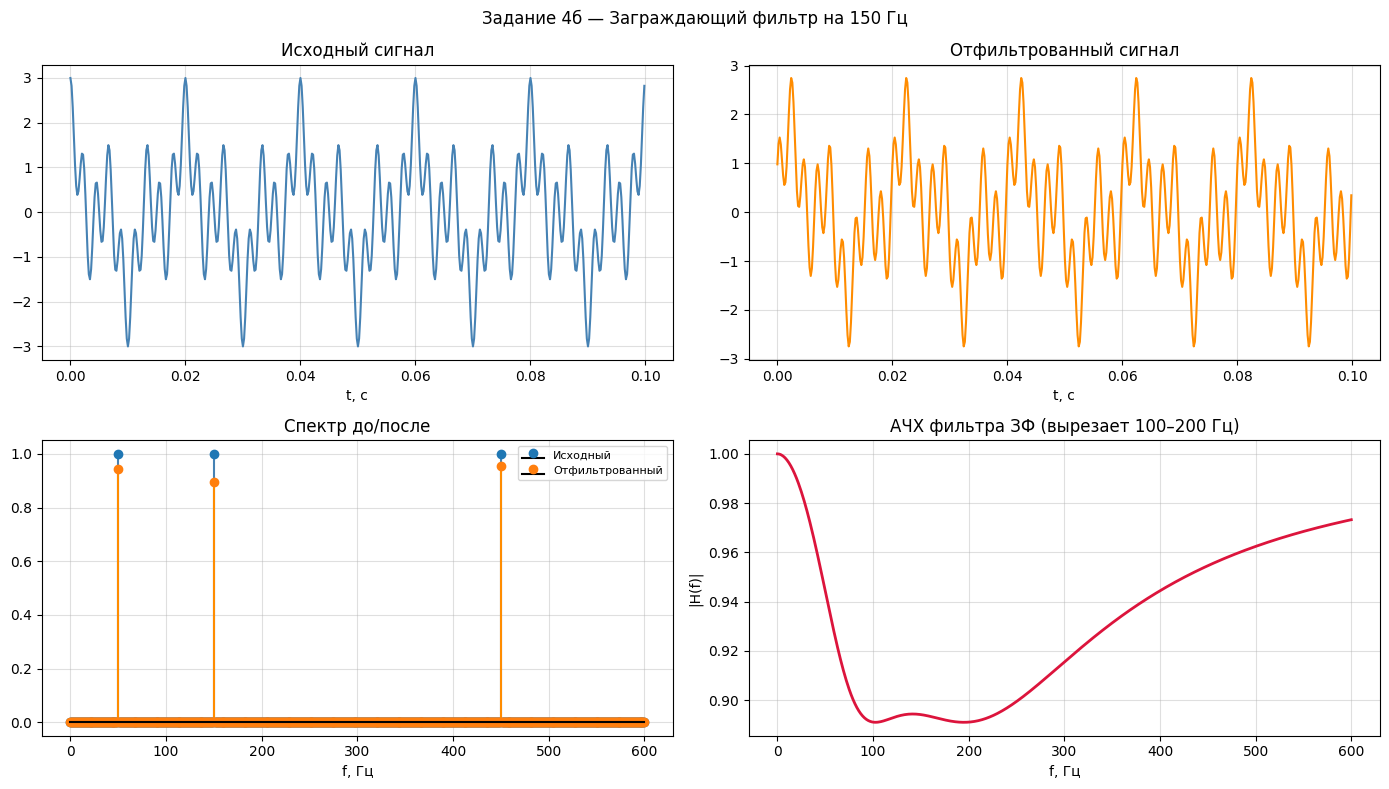

Заграждающий фильтр:
   Частота |       До |    После | Осталось
------------------------------------------
      50 Гц |   1.0000 |   0.9444 | 94.4%
     150 Гц |   1.0000 |   0.8942 | 89.4%
     450 Гц |   1.0000 |   0.9546 | 95.5%


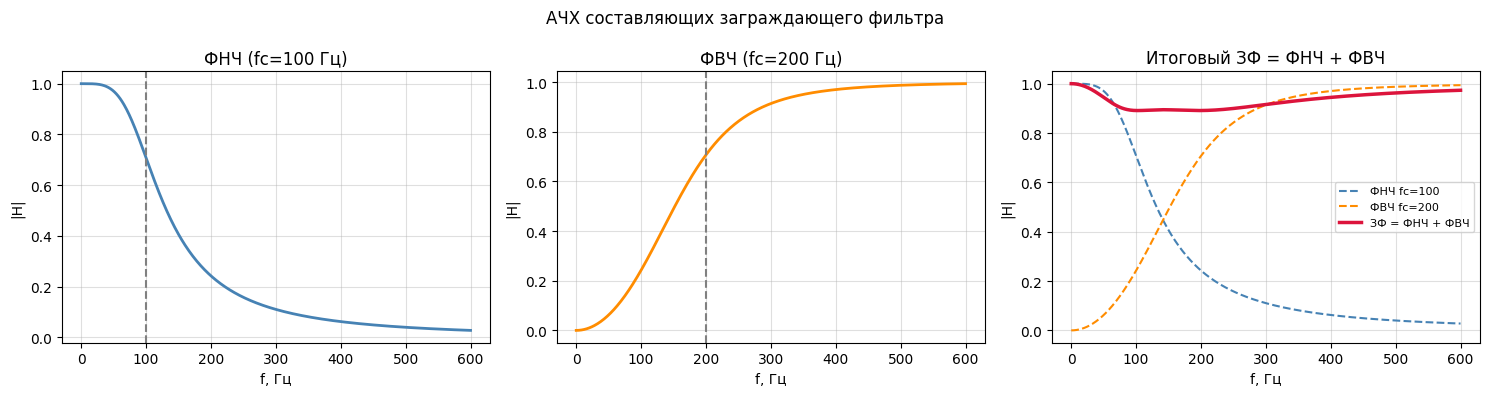

In [11]:
w = 2*np.pi*freqs_full

# ── Строительные блоки ──────────────────────────────────────────────────────
def H_lpf(wc, w):
    """ФНЧ Баттерворта 2-го порядка (формула 32)"""
    return wc**2 / (-w**2 + 1j*np.sqrt(2)*wc*w + wc**2)

def H_hpf(wc, w):
    """ФВЧ Баттерворта 2-го порядка (формула 35)"""
    return w**2 / (-wc**2 + 1j*np.sqrt(2)*wc*w + w**2)

wp1 = 2*np.pi*100   # нижняя граница полосы (Гц)
wp2 = 2*np.pi*200   # верхняя граница полосы (Гц)

# ── Полосовой фильтр (формула 36) ───────────────────────────────────────────
H_bp = H_lpf(wp2, w) * H_hpf(wp1, w)   # произведение ФНЧ и ФВЧ

x_bp = apply_filter_fd(x, H_bp)
_, Xf_bp, _, _ = fft_spectrum(x_bp)

plot_4(t, x, x_bp, freqs_pos, X_mag, Xf_bp,
       np.abs(H_bp[:N//2]),
       fc_label='ПФ (100–200 Гц)',
       title='Задание 4а — Полосовой фильтр на 150 Гц')
print("Полосовой фильтр:")
print_amps(freqs_pos, X_mag, Xf_bp)

# АЧХ составляющих полосового фильтра
mask600 = freqs_pos <= 600
H_lpf_bp_plot = np.abs(H_lpf(wp2, 2*np.pi*freqs_pos))  # ФНЧ fc=200
H_hpf_bp_plot = np.abs(H_hpf(wp1, 2*np.pi*freqs_pos))  # ФВЧ fc=100
H_bp_plot     = np.abs(H_bp[:N//2])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('АЧХ составляющих полосового фильтра')
axes[0].plot(freqs_pos[mask600], H_lpf_bp_plot[mask600], 'steelblue', lw=2)
axes[0].set_title('ФНЧ (fc=200 Гц)'); axes[0].set_xlabel('f, Гц'); axes[0].set_ylabel('|H|')
axes[0].axvline(200, color='gray', ls='--')
axes[1].plot(freqs_pos[mask600], H_hpf_bp_plot[mask600], 'darkorange', lw=2)
axes[1].set_title('ФВЧ (fc=100 Гц)'); axes[1].set_xlabel('f, Гц'); axes[1].set_ylabel('|H|')
axes[1].axvline(100, color='gray', ls='--')
axes[2].plot(freqs_pos[mask600], H_lpf_bp_plot[mask600], 'steelblue', lw=1.5, ls='--', label='ФНЧ fc=200')
axes[2].plot(freqs_pos[mask600], H_hpf_bp_plot[mask600], 'darkorange', lw=1.5, ls='--', label='ФВЧ fc=100')
axes[2].plot(freqs_pos[mask600], H_bp_plot[mask600], 'crimson', lw=2.5, label='ПФ = ФНЧ × ФВЧ')
axes[2].set_title('Итоговый ПФ = ФНЧ × ФВЧ'); axes[2].set_xlabel('f, Гц'); axes[2].set_ylabel('|H|')
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── Заграждающий фильтр (формула 38) ────────────────────────────────────────
H_bs = H_lpf(wp1, w) + H_hpf(wp2, w)   # сумма ФНЧ и ФВЧ

x_bs = apply_filter_fd(x, H_bs)
_, Xf_bs, _, _ = fft_spectrum(x_bs)

plot_4(t, x, x_bs, freqs_pos, X_mag, Xf_bs,
       np.abs(H_bs[:N//2]),
       fc_label='ЗФ (вырезает 100–200 Гц)',
       title='Задание 4б — Заграждающий фильтр на 150 Гц')
print("Заграждающий фильтр:")
print_amps(freqs_pos, X_mag, Xf_bs)

# АЧХ составляющих заграждающего фильтра
H_lpf_bs_plot = np.abs(H_lpf(wp1, 2*np.pi*freqs_pos))  # ФНЧ fc=100
H_hpf_bs_plot = np.abs(H_hpf(wp2, 2*np.pi*freqs_pos))  # ФВЧ fc=200
H_bs_plot     = np.abs(H_bs[:N//2])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('АЧХ составляющих заграждающего фильтра')
axes[0].plot(freqs_pos[mask600], H_lpf_bs_plot[mask600], 'steelblue', lw=2)
axes[0].set_title('ФНЧ (fc=100 Гц)'); axes[0].set_xlabel('f, Гц'); axes[0].set_ylabel('|H|')
axes[0].axvline(100, color='gray', ls='--')
axes[1].plot(freqs_pos[mask600], H_hpf_bs_plot[mask600], 'darkorange', lw=2)
axes[1].set_title('ФВЧ (fc=200 Гц)'); axes[1].set_xlabel('f, Гц'); axes[1].set_ylabel('|H|')
axes[1].axvline(200, color='gray', ls='--')
axes[2].plot(freqs_pos[mask600], H_lpf_bs_plot[mask600], 'steelblue', lw=1.5, ls='--', label='ФНЧ fc=100')
axes[2].plot(freqs_pos[mask600], H_hpf_bs_plot[mask600], 'darkorange', lw=1.5, ls='--', label='ФВЧ fc=200')
axes[2].plot(freqs_pos[mask600], H_bs_plot[mask600], 'crimson', lw=2.5, label='ЗФ = ФНЧ + ФВЧ')
axes[2].set_title('Итоговый ЗФ = ФНЧ + ФВЧ'); axes[2].set_xlabel('f, Гц'); axes[2].set_ylabel('|H|')
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## Задание 5. ФНЧ Баттерворта произвольного порядка (формулы 28, 29)


Полюсы:
$$S_k = \exp\!\left(j\,\frac{\pi(2k+n-1)}{2n}\right), \quad k = 1,2,\ldots,2n$$

Нормированная передаточная функция (формула 29):
$$H_n(S) = \frac{1}{\prod_{k=1}^{n}(S - S_k)}$$

Для ненормированной частоты делаем замену $S = p/\omega_c = j\omega/\omega_c$.

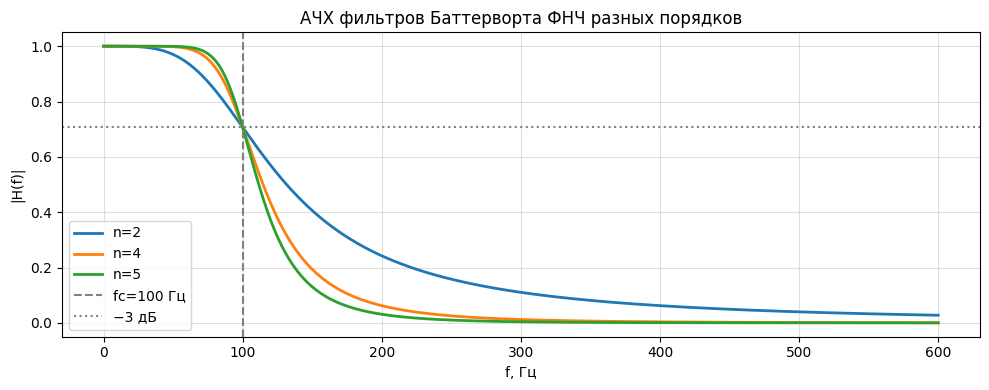

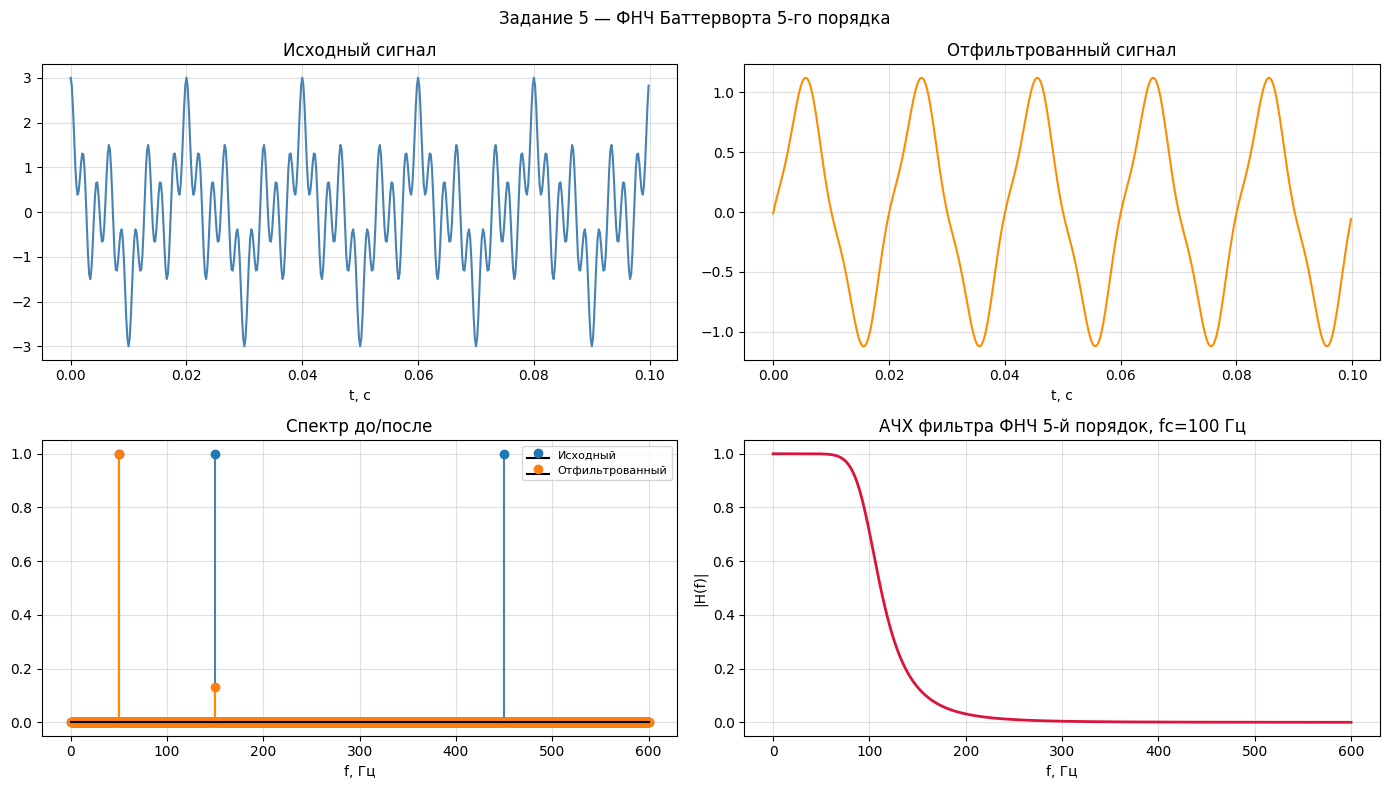

Фильтр 5-го порядка:
   Частота |       До |    После | Осталось
------------------------------------------
      50 Гц |   1.0000 |   0.9995 | 100.0%
     150 Гц |   1.0000 |   0.1306 | 13.1%
     450 Гц |   1.0000 |   0.0005 | 0.1%


In [ ]:
def butterworth_lpf(order, fc, freqs_hz):
    """
    ФНЧ Баттерворта произвольного порядка.
    Возвращает комплексную передаточную функцию H(f) для всех freqs_hz.
    Реализует формулы (28) и (29) из методички.
    """
    n  = order
    wc = 2*np.pi*fc
    w  = 2*np.pi*np.array(freqs_hz, dtype=complex)

    k_all = np.arange(1, 2*n+1)
    S_all = np.exp(1j * np.pi * (2*k_all + n - 1) / (2*n))

    S_left = S_all[np.real(S_all) < 0]

    S_jw = 1j * w / wc   # shape (len(w),)
    denom = np.ones_like(S_jw)
    for pole in S_left:
        denom *= (S_jw - pole)

    return 1.0 / denom

# ── Фильтры 4-го и 5-го порядка ────────────────────────────────────────────
fc_test = 100

H4 = butterworth_lpf(4, fc_test, freqs_full)
H5 = butterworth_lpf(5, fc_test, freqs_full)

x_filt4 = apply_filter_fd(x, H4)
x_filt5 = apply_filter_fd(x, H5)

_, Xf4, _, _ = fft_spectrum(x_filt4)
_, Xf5, _, _ = fft_spectrum(x_filt5)

mask600 = freqs_pos <= 600

# График АЧХ для порядков 2, 4, 5
H2_plot = np.abs(butterworth_lpf(2, fc_test, freqs_pos))
H4_plot = np.abs(H4[:N//2])
H5_plot = np.abs(H5[:N//2])

plt.figure(figsize=(10,4))
plt.plot(freqs_pos[mask600], H2_plot[mask600], label='n=2', lw=2)
plt.plot(freqs_pos[mask600], H4_plot[mask600], label='n=4', lw=2)
plt.plot(freqs_pos[mask600], H5_plot[mask600], label='n=5', lw=2)
plt.axvline(fc_test, color='gray', ls='--', label=f'fc={fc_test} Гц')
plt.axhline(1/np.sqrt(2), color='gray', ls=':', label='−3 дБ')
plt.title('АЧХ фильтров Баттерворта ФНЧ разных порядков')
plt.xlabel('f, Гц'); plt.ylabel('|H(f)|'); plt.legend()
plt.tight_layout(); plt.show()

plot_4(t, x, x_filt5, freqs_pos, X_mag, Xf5,
       H5_plot,
       fc_label=f'ФНЧ 5-й порядок, fc={fc_test} Гц',
       title='Задание 5 — ФНЧ Баттерворта 5-го порядка')

print("Фильтр 5-го порядка:")
print_amps(freqs_pos, X_mag, Xf5)

---
## Задание 6. Сравнение фильтров 2-го и 5-го порядка

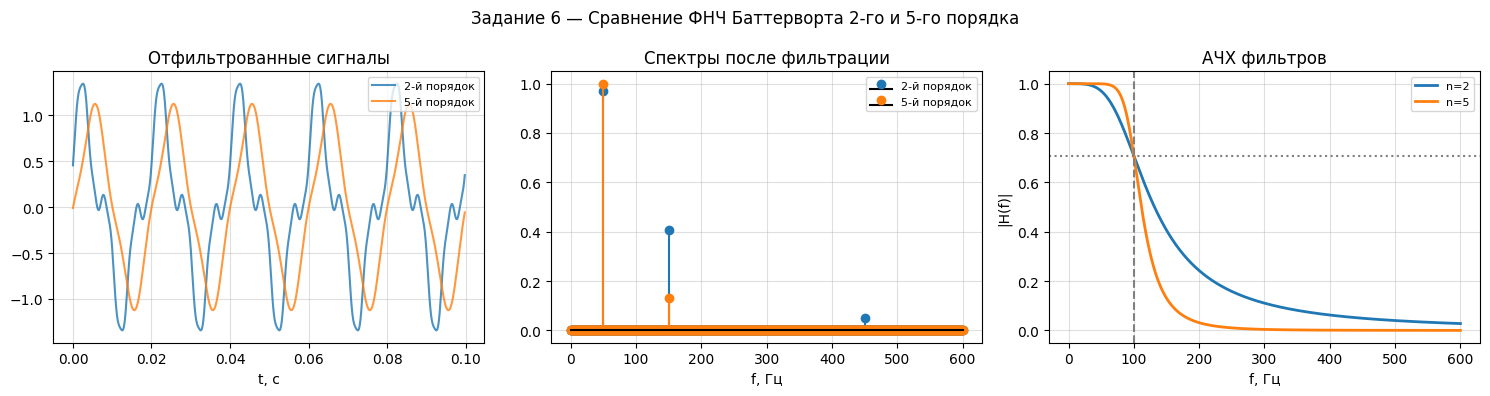

Сравнение амплитуд после фильтрации:
   Частота |      n=2 |      n=5
-----------------------------------
      50 Гц |   0.9701 |   0.9995
     150 Гц |   0.4061 |   0.1306
     450 Гц |   0.0493 |   0.0005


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Задание 6 — Сравнение ФНЧ Баттерворта 2-го и 5-го порядка')

# Сигналы
axes[0].plot(t[:500], x_lpf2[:500], label='2-й порядок', alpha=0.8)
axes[0].plot(t[:500], x_filt5[:500], label='5-й порядок', alpha=0.8)
axes[0].set_title('Отфильтрованные сигналы'); axes[0].set_xlabel('t, с')
axes[0].legend(fontsize=8)

# Спектры
axes[1].stem(freqs_pos[mask600], Xf_lpf2[mask600],
             linefmt='C0', markerfmt='C0o', basefmt='k-', label='2-й порядок')
axes[1].stem(freqs_pos[mask600], Xf5[mask600],
             linefmt='C1', markerfmt='C1o', basefmt='k-', label='5-й порядок')
axes[1].set_title('Спектры после фильтрации'); axes[1].set_xlabel('f, Гц')
axes[1].legend(fontsize=8)

# АЧХ
axes[2].plot(freqs_pos[mask600], H2_plot[mask600], lw=2, label='n=2')
axes[2].plot(freqs_pos[mask600], H5_plot[mask600], lw=2, label='n=5')
axes[2].axvline(fc_test, color='gray', ls='--')
axes[2].axhline(1/np.sqrt(2), color='gray', ls=':')
axes[2].set_title('АЧХ фильтров'); axes[2].set_xlabel('f, Гц'); axes[2].set_ylabel('|H(f)|')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

print("Сравнение амплитуд после фильтрации:")
print(f"{'Частота':>10} | {'n=2':>8} | {'n=5':>8}")
print('-'*35)
for f in [50, 150, 450]:
    a2 = peak_amp(Xf_lpf2, freqs_pos, f)
    a5 = peak_amp(Xf5,     freqs_pos, f)
    print(f"{f:>8} Гц | {a2:>8.4f} | {a5:>8.4f}")

---
## Задание 7. Сравнение своего ФНЧ 5-го порядка с `scipy.signal.butter`

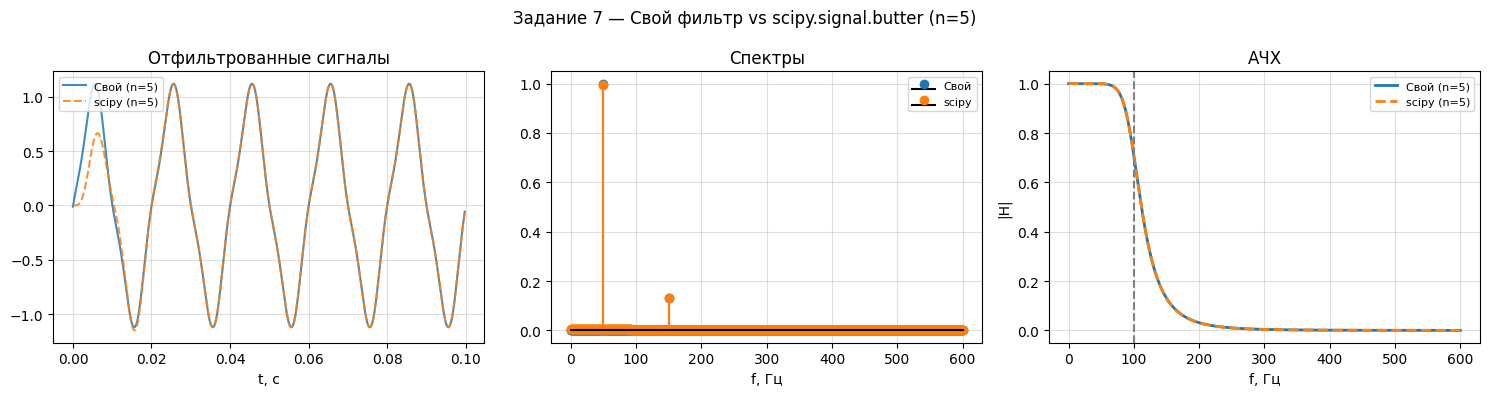

Сравнение амплитуд:
   Частота |     Свой |    scipy
-----------------------------------
      50 Гц |   0.9995 |   0.9947
     150 Гц |   0.1306 |   0.1297
     450 Гц |   0.0005 |   0.0005


In [13]:
# ── scipy.signal.butter ─────────────────────────────────────────────────────
b, a = sp.butter(5, fc_test / (fs/2), btype='low')   # fc нормируется на fs/2
x_scipy = sp.lfilter(b, a, x)                         # фильтрация во временной области
_, Xf_scipy, _, _ = fft_spectrum(x_scipy)

# АЧХ scipy-фильтра через freqz
freq_resp, h_scipy = sp.freqz(b, a, worN=N//2, fs=fs)

# ── Сравнение ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Задание 7 — Свой фильтр vs scipy.signal.butter (n=5)')

axes[0].plot(t[:500], x_filt5[:500],  label='Свой (n=5)', alpha=0.85)
axes[0].plot(t[:500], x_scipy[:500], label='scipy (n=5)', alpha=0.85, ls='--')
axes[0].set_title('Отфильтрованные сигналы'); axes[0].set_xlabel('t, с'); axes[0].legend(fontsize=8)

axes[1].stem(freqs_pos[mask600], Xf5[mask600],
             linefmt='C0', markerfmt='C0o', basefmt='k-', label='Свой')
axes[1].stem(freqs_pos[mask600], Xf_scipy[mask600],
             linefmt='C1', markerfmt='C1o', basefmt='k-', label='scipy')
axes[1].set_title('Спектры'); axes[1].set_xlabel('f, Гц'); axes[1].legend(fontsize=8)

axes[2].plot(freqs_pos[mask600], H5_plot[mask600], lw=2, label='Свой (n=5)')
axes[2].plot(freq_resp[freq_resp<=600], np.abs(h_scipy[freq_resp<=600]),
             lw=2, ls='--', label='scipy (n=5)')
axes[2].axvline(fc_test, color='gray', ls='--')
axes[2].set_title('АЧХ'); axes[2].set_xlabel('f, Гц'); axes[2].set_ylabel('|H|')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

# Численное сравнение
print("Сравнение амплитуд:")
print(f"{'Частота':>10} | {'Свой':>8} | {'scipy':>8}")
print('-'*35)
for f in [50, 150, 450]:
    a_my  = peak_amp(Xf5,      freqs_pos, f)
    a_sc  = peak_amp(Xf_scipy, freqs_pos, f)
    print(f"{f:>8} Гц | {a_my:>8.4f} | {a_sc:>8.4f}")


---
## Задание 8. Фильтрация зашумлённого сигнала

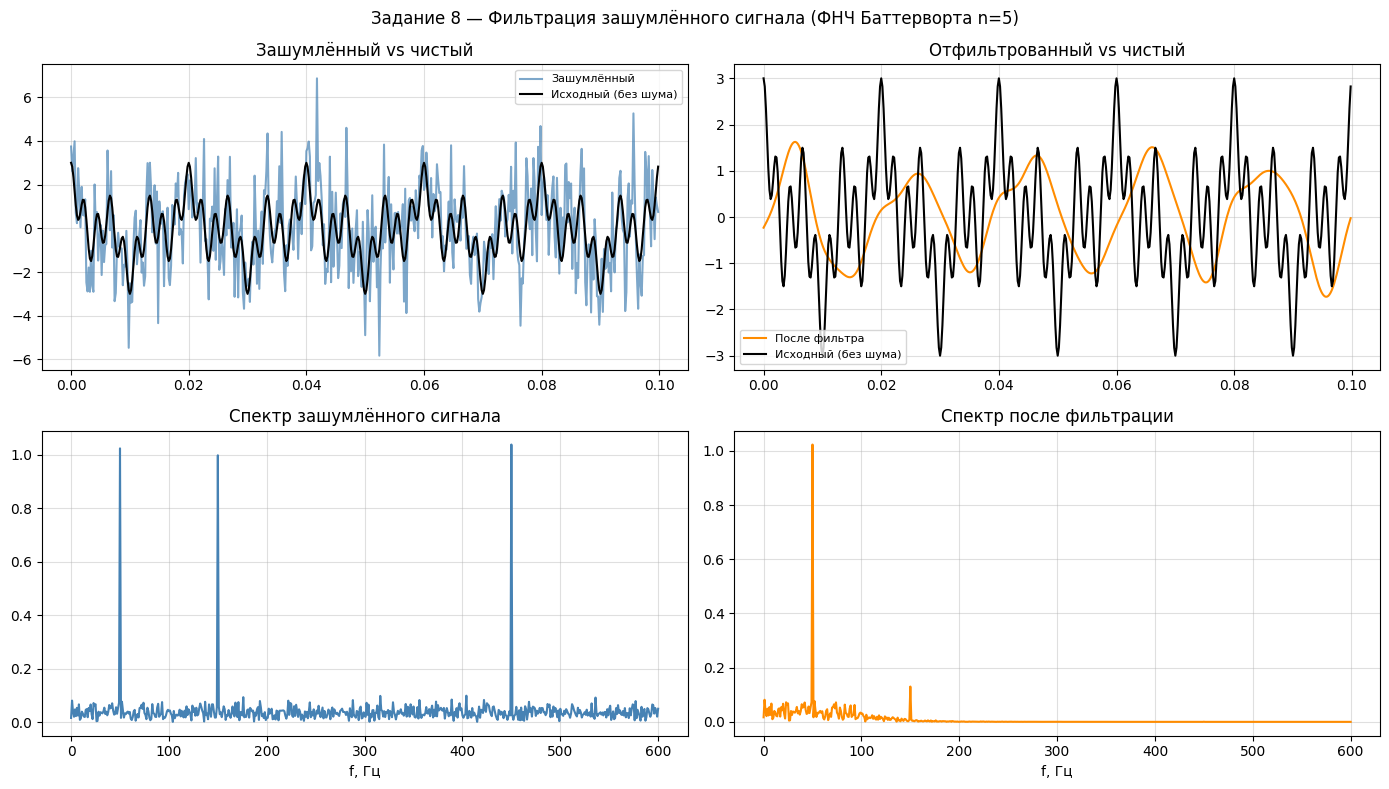

SNR до фильтрации:    -1.7 дБ
SNR после фильтрации: -1.6 дБ
Улучшение SNR:        0.1 дБ


In [14]:
np.random.seed(42)
noise_level = 1.5
noise   = noise_level * np.random.randn(N)
x_noisy = x + noise

# Фильтруем зашумлённый сигнал нашим ФНЧ 5-го порядка
x_noisy_filt = apply_filter_fd(x_noisy, H5)

_, X_noisy_mag,   _, _ = fft_spectrum(x_noisy)
_, Xf_noisy_mag,  _, _ = fft_spectrum(x_noisy_filt)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Задание 8 — Фильтрация зашумлённого сигнала (ФНЧ Баттерворта n=5)')

axes[0,0].plot(t[:500], x_noisy[:500], 'steelblue', alpha=0.7, label='Зашумлённый')
axes[0,0].plot(t[:500], x[:500], 'k', lw=1.5, label='Исходный (без шума)')
axes[0,0].set_title('Зашумлённый vs чистый'); axes[0,0].legend(fontsize=8)

axes[0,1].plot(t[:500], x_noisy_filt[:500], 'darkorange', label='После фильтра')
axes[0,1].plot(t[:500], x[:500], 'k', lw=1.5, label='Исходный (без шума)')
axes[0,1].set_title('Отфильтрованный vs чистый'); axes[0,1].legend(fontsize=8)

axes[1,0].plot(freqs_pos[mask600], X_noisy_mag[mask600], 'steelblue')
axes[1,0].set_title('Спектр зашумлённого сигнала'); axes[1,0].set_xlabel('f, Гц')

axes[1,1].plot(freqs_pos[mask600], Xf_noisy_mag[mask600], 'darkorange')
axes[1,1].set_title('Спектр после фильтрации'); axes[1,1].set_xlabel('f, Гц')

plt.tight_layout(); plt.show()

# Оценка SNR
snr_before = 10*np.log10(np.var(x) / np.var(noise))
snr_after  = 10*np.log10(np.var(x) / np.var(x_noisy_filt - x))
print(f"SNR до фильтрации:    {snr_before:.1f} дБ")
print(f"SNR после фильтрации: {snr_after:.1f} дБ")
print(f"Улучшение SNR:        {snr_after - snr_before:.1f} дБ")


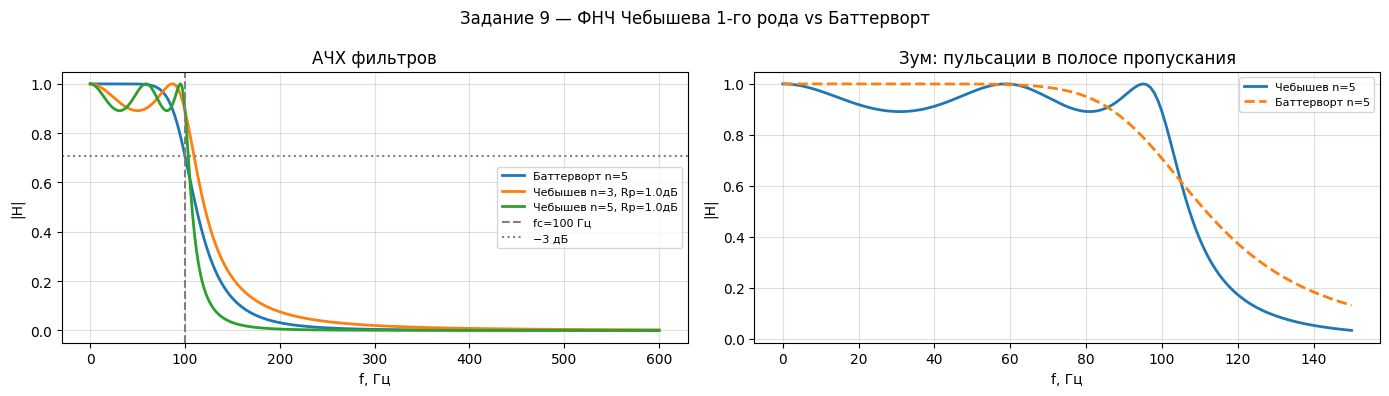

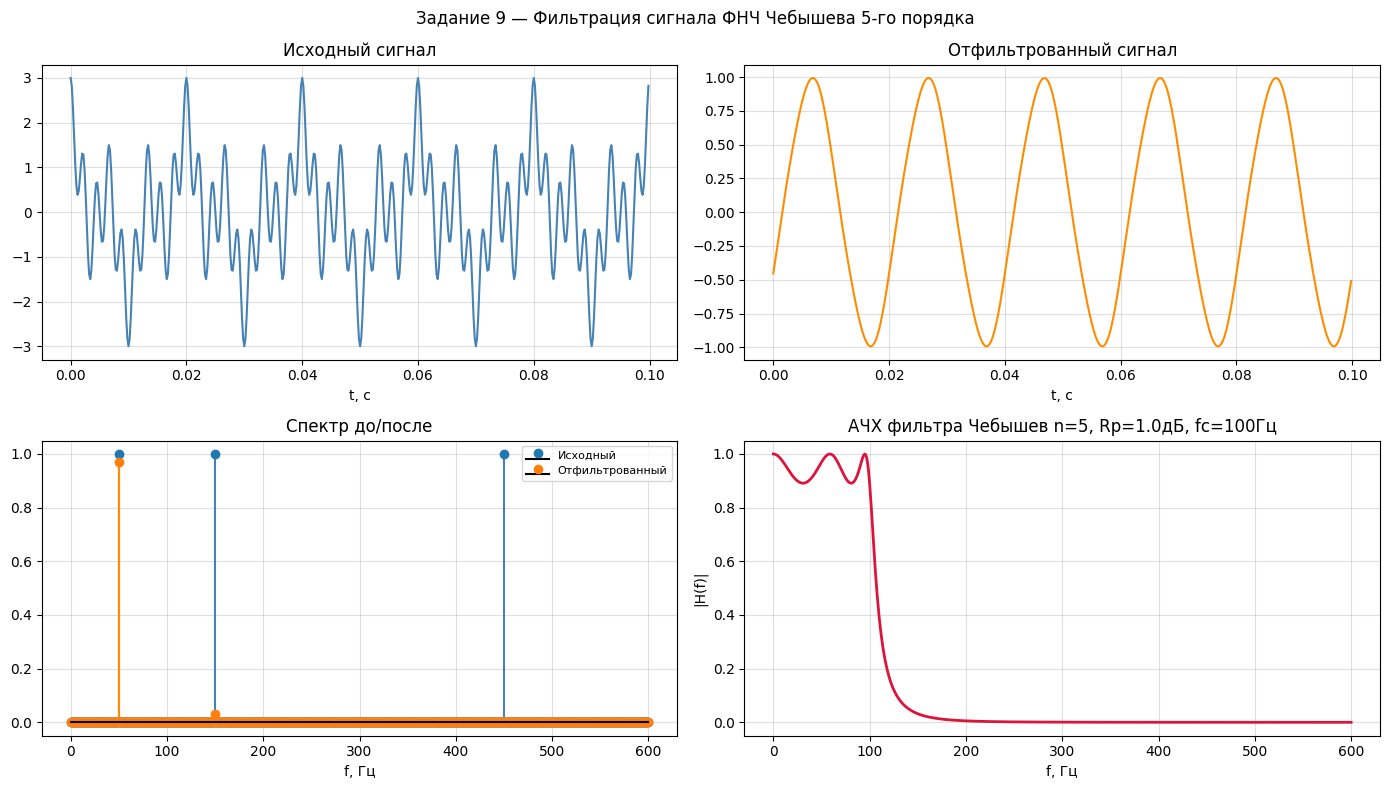

Чебышев n=5 vs Баттерворт n=5:
   Частота |    Чебышев |   Баттерворт
----------------------------------------
      50 Гц |     0.9691 |       0.9995
     150 Гц |     0.0319 |       0.1306
     450 Гц |     0.0001 |       0.0005


In [15]:
def chebyshev1_lpf(order, fc, rp_db, freqs_hz):
    """
    ФНЧ Чебышева 1-го рода.
    order   — порядок фильтра
    fc      — частота среза (Гц)
    rp_db   — пульсации в полосе пропускания (дБ), обычно 0.5–3 дБ
    freqs_hz — массив частот
    """
    n  = order
    wc = 2*np.pi*fc
    w  = 2*np.pi*np.array(freqs_hz, dtype=complex)

    # Параметр пульсаций
    eps = np.sqrt(10**(rp_db/10) - 1)

    # Углы полюсов
    k = np.arange(1, n+1)
    theta = np.pi * (2*k - 1) / (2*n)

    # Полюсы на эллипсе (нормированная плоскость S)
    sigma = -np.sinh((1/n) * np.arcsinh(1/eps)) * np.sin(theta)
    omega =  np.cosh((1/n) * np.arcsinh(1/eps)) * np.cos(theta)
    S_poles = sigma + 1j*omega   # все n полюсов уже в левой полуплоскости

    # Нормировочный коэффициент H0 чтобы |H(0)| = 1
    H0 = np.prod(np.abs(S_poles))

    # Ненормированная частота: S = j*w/wc
    S_jw = 1j * w / wc
    denom = np.ones_like(S_jw)
    for pole in S_poles:
        denom *= (S_jw - pole)

    return H0 / denom


# ── Строим и сравниваем ─────────────────────────────────────────────────────
fc_ch = 100
rp    = 1.0   # пульсации 1 дБ

H_ch3 = chebyshev1_lpf(3, fc_ch, rp, freqs_full)
H_ch5 = chebyshev1_lpf(5, fc_ch, rp, freqs_full)

x_ch5 = apply_filter_fd(x, H_ch5)
_, Xf_ch5, _, _ = fft_spectrum(x_ch5)

# АЧХ: Чебышев vs Баттерворт
mask600 = freqs_pos <= 600
H_bt5 = np.abs(butterworth_lpf(5, fc_ch, freqs_pos))
H_c3  = np.abs(H_ch3[:N//2])
H_c5  = np.abs(H_ch5[:N//2])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Задание 9 — ФНЧ Чебышева 1-го рода vs Баттерворт')

axes[0].plot(freqs_pos[mask600], H_bt5[mask600], lw=2, label='Баттерворт n=5')
axes[0].plot(freqs_pos[mask600], H_c3[mask600],  lw=2, label=f'Чебышев n=3, Rp={rp}дБ')
axes[0].plot(freqs_pos[mask600], H_c5[mask600],  lw=2, label=f'Чебышев n=5, Rp={rp}дБ')
axes[0].axvline(fc_ch, color='gray', ls='--', label=f'fc={fc_ch} Гц')
axes[0].axhline(1/np.sqrt(2), color='gray', ls=':', label='−3 дБ')
axes[0].set_title('АЧХ фильтров'); axes[0].set_xlabel('f, Гц'); axes[0].set_ylabel('|H|')
axes[0].legend(fontsize=8)

# Зум на полосу пропускания — видны пульсации
axes[1].plot(freqs_pos[freqs_pos<=150], H_c5[freqs_pos<=150], lw=2, label='Чебышев n=5')
axes[1].plot(freqs_pos[freqs_pos<=150], H_bt5[freqs_pos<=150], lw=2, ls='--', label='Баттерворт n=5')
axes[1].set_title('Зум: пульсации в полосе пропускания')
axes[1].set_xlabel('f, Гц'); axes[1].set_ylabel('|H|')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

# 4 графика для Чебышева n=5
plot_4(t, x, x_ch5, freqs_pos, X_mag, Xf_ch5,
       H_c5, fc_label=f'Чебышев n=5, Rp={rp}дБ, fc={fc_ch}Гц',
       title='Задание 9 — Фильтрация сигнала ФНЧ Чебышева 5-го порядка')

# Таблица
print("Чебышев n=5 vs Баттерворт n=5:")
print(f"{'Частота':>10} | {'Чебышев':>10} | {'Баттерворт':>12}")
print('-'*40)
for f in [50, 150, 450]:
    ac = peak_amp(Xf_ch5, freqs_pos, f)
    ab = peak_amp(Xf5,    freqs_pos, f)
    print(f"{f:>8} Гц | {ac:>10.4f} | {ab:>12.4f}")